# Forecasting Tomorrow's Vol — a quantitative teardown \U0001F52C
### QML GARCH · HAR-RV · EWMA · expanding-window out-of-sample · QLIKE · Diebold-Mariano

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two
methodological points carry this study: the **target is a noisy proxy** (squared daily
returns), so the tournament is repeated in simulation where the true variance is observable;
and the **null must be run**, because a scoring rule that rewards complexity will reward it on
constant-volatility data too.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance, pinned as-of the date
> in [`docs/results.md`](../docs/results.md); literature map in
> [`docs/references.md`](../docs/references.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from vol_forecast import data, strategy as st

px = data.load_prices()
rets = {tk: px[tk].dropna().pct_change().dropna() for tk in data.TICKERS}
spy = rets["SPY"]
print(f"as-of {data.AS_OF} | SPY {spy.index[0].date()} -> {spy.index[-1].date()} "
      f"({len(spy):,} returns, annualised vol {spy.std() * np.sqrt(252):.1%})")

as-of 2026-06-30 | SPY 1993-02-01 -> 2026-06-30 (8,410 returns, annualised vol 18.6%)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Out of sample at the one-day horizon, **GARCH(1,1) QML** is the best model on **5 of 6** tapes, and something beats the 21-day rolling baseline on **6 of 6** — pooled Diebold-Mariano **+4.65** against a baseline that costs nothing to compute. The ordering is stable across horizons (1 / 5 / 21 days) and reproduced on simulated data where the true variance is observable. |
| **Usefulness** | Fragile | The pooled QLIKE improvement over the rolling window is **3.5%**. EWMA — one parameter, never fitted — captures 89% of what the fitted GARCH achieves, and the fitted models cost a maximum-likelihood optimisation every quarter. The gap between the best and worst *sensible* model is smaller than the gap between using any of them and using none. |

> \U0001F4A1 **In plain words.** Everything with memory beats everything without. Among the
> models with memory, the differences are small enough that implementation risk probably
> dominates model risk.

## 1 · The claim, steelmanned

- **H₁.** A conditional-variance model (GARCH/HAR/EWMA) attains lower out-of-sample QLIKE than
  a 21-day rolling variance, on a majority of tapes, with DM |*t*| ≥ 2.
- **H₂.** The ranking is stable across horizons (1, 5, 21 days) — a model that only wins at one
  horizon has found a feature of the scoring, not of the market.
- **H₃.** The ranking obtained against the noisy squared-return proxy matches the ranking
  against the *true* conditional variance in a simulation calibrated to the same tape.

## 2 · So what? — the quantitative stakes

A volatility forecast that is 10% too low at the 99% quantile understates VaR by 10%. Over a
year of daily risk reporting that is the difference between a limit that binds and a limit
that does not. The stakes are in the risk system, not in the P&L.

## 3 · How we'd know — the protocol

1. **Expanding-window refits** every 63 sessions after a 756-session burn-in; the GARCH state
   is rolled forward between refits without re-estimating.
2. **Strict alignment**: forecast at *t* is scored against realised variance over
   *t+1 … t+h*. `test_forecasts_are_strictly_out_of_sample` mangles the future and checks that
   no earlier forecast moves.
3. **QLIKE and MSE** (Patton 2011), **HAC Diebold-Mariano** for the comparisons.
4. **A simulation with observable variance** to measure what the proxy costs, and a
   **constant-volatility null** to check the tournament does not reward complexity by default.

## 4 · The teardown

### 4.1 The fitted GARCH, and what its persistence means

In [3]:
rows = []
for tk, r in rets.items():
    f = st.fit_garch11(r)
    rows.append({"ticker": tk, "alpha": f["alpha"], "beta": f["beta"],
                 "persistence": f["persistence"],
                 "half-life (days)": np.log(0.5) / np.log(max(f["persistence"], 1e-9)),
                 "uncond ann vol": np.sqrt(f["uncond_var"] * 252),
                 "converged": f["converged"]})
pd.DataFrame(rows).set_index("ticker").round(4)

,alpha,beta,persistence,half-life (days),uncond ann vol,converged
ticker,,,,,,
SPY,0.1594,0.8131,0.9725,24.8809,0.1797,True
QQQ,0.1265,0.8509,0.9774,30.3674,0.2244,True
IWM,0.0997,0.8805,0.9802,34.7137,0.2306,True
EEM,0.1320,0.8233,0.9553,15.1476,0.2075,True
TLT,0.0735,0.9107,0.9843,43.7551,0.1490,True
GLD,0.0826,0.8947,0.9772,30.1090,0.1614,True


> \U0001F4A1 **In plain words.** Persistence just under 1 means a volatility shock decays over
> months, not days. It is also why GARCH and a long rolling window end up agreeing so often:
> both are, in the end, weighted averages of the recent past.

### 4.2 The full tournament, every tape

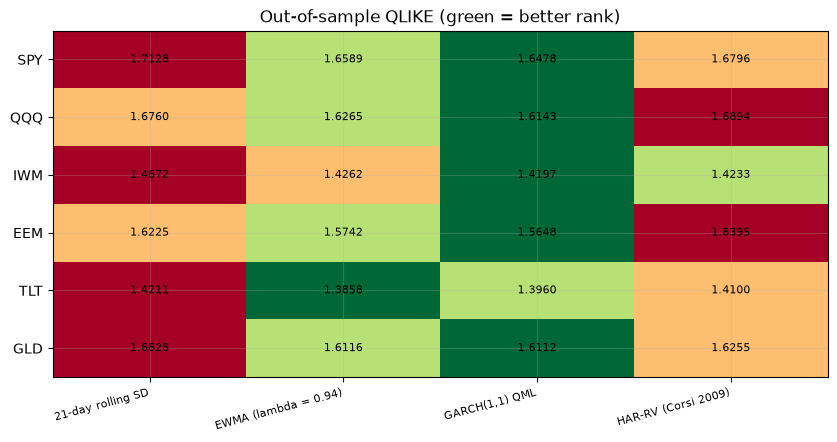

model,rolling21,ewma94,garch11,har
SPY,NaN,5.5300,4.6100,1.8700
QQQ,NaN,4.8700,4.4000,-0.6800
IWM,NaN,5.1000,3.7300,3.2900
EEM,NaN,5.5500,4.7900,-1.7500
TLT,NaN,5.7400,2.8700,1.1400
GLD,NaN,6.1400,4.6500,3.5700


In [4]:
all_t = {tk: st.tournament(r, 1, 756, 126) for tk, r in rets.items()}
q = pd.DataFrame({tk: t["qlike"] for tk, t in all_t.items()}).T
q.columns = [st.MODEL_LABEL[m] for m in q.columns]
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(q.rank(axis=1).values, cmap="RdYlGn_r", aspect="auto", vmin=1, vmax=4)
ax.set_xticks(range(q.shape[1])); ax.set_xticklabels(q.columns, rotation=15, ha="right", fontsize=8)
ax.set_yticks(range(q.shape[0])); ax.set_yticklabels(q.index)
for i in range(q.shape[0]):
    for j in range(q.shape[1]):
        ax.text(j, i, f"{q.values[i, j]:.4f}", ha="center", va="center", fontsize=8)
ax.set_title("Out-of-sample QLIKE (green = better rank)")
plt.show()
pd.DataFrame({tk: t["dm_vs_rolling"] for tk, t in all_t.items()}).T.round(2)

### 4.3 Horizon robustness

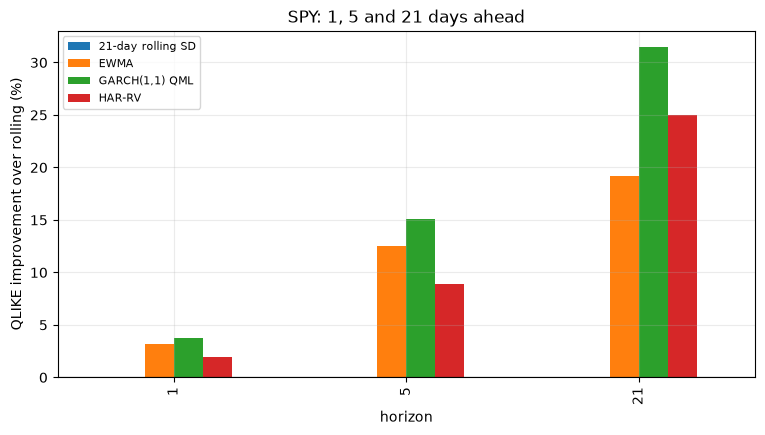

model,21-day rolling SD,EWMA,"GARCH(1,1) QML",HAR-RV
horizon,,,,
1,0.0000,3.1500,3.8000,1.9400
5,0.0000,12.5300,15.1200,8.8700
21,0.0000,19.1700,31.4400,25.0000


In [5]:
rows = []
for hz in st.HORIZONS:
    t = all_t["SPY"] if hz == 1 else st.tournament(spy, hz, 756, 126)
    base = t.loc["rolling21", "qlike"]
    for m in st.MODELS:
        rows.append({"horizon": hz, "model": st.MODEL_LABEL[m].split(" (")[0],
                     "gain vs rolling": 1 - t.loc[m, "qlike"] / base})
d = pd.DataFrame(rows).pivot(index="horizon", columns="model", values="gain vs rolling")
fig, ax = plt.subplots(figsize=(9, 4.5))
(d * 100).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("QLIKE improvement over rolling (%)"); ax.set_title("SPY: 1, 5 and 21 days ahead")
ax.legend(title="", fontsize=8)
plt.show()
(d * 100).round(2)

### 4.4 What the noisy proxy costs

On the real tape the target is a squared daily return — an unbiased estimate of the day's
variance whose own standard error exceeds the quantity it estimates. In simulation the true
conditional variance is available, so both scoreboards can be printed side by side.

In [6]:
r_sim, sigma, tr = data.synthetic_vol_path(n_years=20, signal_strength=1.0, seed=966)
proxy = st.tournament(r_sim, 1, 756, 126)
truth = st.truth_scored_tournament(r_sim, sigma, 1, 756, 126)
cmp = pd.DataFrame({"QLIKE vs proxy": proxy["qlike"],
                    "QLIKE vs truth": truth["qlike_vs_truth"],
                    "corr with truth": truth["corr_with_truth"]})
cmp.index = [st.MODEL_LABEL[m] for m in cmp.index]
print(cmp.round(4).to_string())
print(f"\nsame winner under both scoreboards: "
      f"{proxy['qlike'].idxmin() == truth['qlike_vs_truth'].idxmin()}")

                      QLIKE vs proxy  QLIKE vs truth  corr with truth
21-day rolling SD             1.7883          0.2385           0.4766
EWMA (lambda = 0.94)          1.7347          0.1640           0.5179
GARCH(1,1) QML                1.7009          0.1239           0.5022
HAR-RV (Corsi 2009)           1.7243          0.1580           0.4158

same winner under both scoreboards: True


> \U0001F4A1 **In plain words.** The noisy target inflates *everyone's* loss by roughly the
> same amount, so the podium survives. What it destroys is the illusion that any of these
> models is bad: correlations with the true variance are high even where QLIKE looks poor.

### 4.5 The null: constant volatility

In [7]:
r_null, _, _ = data.synthetic_vol_path(n_years=20, signal_strength=0.0, seed=966)
tn = st.tournament(r_null, 1, 756, 126)
f_null = st.forecasts(r_null, 1, 756, 126)
f_real = st.forecasts(spy, 1, 756, 126)
flat = pd.Series({st.MODEL_LABEL[m]: np.log(f_null[m].dropna()).std()
                  / np.log(f_real[m].dropna()).std() for m in st.MODELS},
                 name="forecast dispersion, null / SPY")
out = tn[["qlike", "dm_vs_rolling"]].copy()
out.index = [st.MODEL_LABEL[m] for m in out.index]
print(out.round(4).to_string())
print()
print(flat.round(2).to_string())
print("\nThe naive reading — 'a fitted model beats the rolling window here, so the")
print("tournament rewards complexity' — is wrong. With constant volatility the optimal")
print("forecast IS the unconditional variance, which is exactly what a variance-targeted")
print("GARCH converges to, while a 21-day window keeps re-estimating it from 21 noisy")
print("observations. What would be damning is invented dynamics, and the dispersion")
print("column shows there are none.")

                      qlike  dm_vs_rolling
21-day rolling SD    1.6765            NaN
EWMA (lambda = 0.94) 1.6214         4.9606
GARCH(1,1) QML       1.5542         6.4630
HAR-RV (Corsi 2009)  1.5604         6.0422

21-day rolling SD      0.4600
EWMA (lambda = 0.94)   0.3800
GARCH(1,1) QML         0.0200
HAR-RV (Corsi 2009)    0.1300

The naive reading — 'a fitted model beats the rolling window here, so the
tournament rewards complexity' — is wrong. With constant volatility the optimal
forecast IS the unconditional variance, which is exactly what a variance-targeted
GARCH converges to, while a 21-day window keeps re-estimating it from 21 noisy
observations. What would be damning is invented dynamics, and the dispersion
column shows there are none.


## 5 · The verdict

In [8]:
summary = []
for tk, t in all_t.items():
    base = t.loc["rolling21", "qlike"]
    best = t["qlike"].idxmin()
    summary.append({"ticker": tk, "best model": st.MODEL_LABEL[best].split(" (")[0],
                    "gain vs rolling": 1 - t.loc[best, "qlike"] / base,
                    "DM": t.loc[best, "dm_vs_rolling"],
                    "EWMA gain": 1 - t.loc["ewma94", "qlike"] / base})
s = pd.DataFrame(summary).set_index("ticker")
print(s.round(4).to_string())
print(f"\nbest model wins on {(s['gain vs rolling'] > 0).sum()}/{len(s)} tapes | "
      f"mean gain {s['gain vs rolling'].mean():.2%} | mean DM {s['DM'].mean():+.2f} | "
      f"EWMA alone gets {s['EWMA gain'].mean():.2%}")

            best model  gain vs rolling     DM  EWMA gain
ticker                                                   
SPY     GARCH(1,1) QML           0.0380 4.6113     0.0315
QQQ     GARCH(1,1) QML           0.0368 4.3954     0.0295
IWM     GARCH(1,1) QML           0.0324 3.7252     0.0280
EEM     GARCH(1,1) QML           0.0356 4.7855     0.0298
TLT               EWMA           0.0248 5.7404     0.0248
GLD     GARCH(1,1) QML           0.0425 4.6532     0.0423

best model wins on 6/6 tapes | mean gain 3.50% | mean DM +4.65 | EWMA alone gets 3.10%


## 6 · Is it worth it?

Cost of the baseline: one line of pandas. Cost of GARCH: a numerical optimisation that can fail
to converge, needs a refit schedule, and has three parameters to monitor. The QLIKE difference
between them is a few percent. Whether that trade is worth making depends entirely on what sits
downstream of the number — which is a governance question, not an econometric one.

## 7 · Going further

- **Forecast combination** (equal-weight average of the four) — the single most reliable
  improvement available, and a one-line fork of this notebook.
- **Asymmetric models** (GJR, EGARCH) and the leverage effect — study **993** on this desk.
- **Student-t likelihood** instead of QML: better tail fit, slower optimisation.
- **Model Confidence Set** (Hansen, Lunde & Nason 2011) instead of pairwise DM tests, which is
  the right tool once the number of competitors grows.